In [23]:
# Task 2 - Step 1A
# Load the saved final model

import joblib

final_model = joblib.load("final_model.pkl")

print("Final model loaded successfully!")

Final model loaded successfully!


In [24]:
# Task 1 - Step 1
# Create the same feature engineering function used in Day 4

import pandas as pd
import numpy as np

def create_features(X):
    X = X.copy()

    # Create age groups
    X['age_group'] = pd.cut(
        X['age'],
        bins=[0, 25, 35, 45, 55, 100],
        labels=['18-25', '26-35', '36-45', '46-55', '56+']
    )

    # Create working hours groups
    X['hours_group'] = pd.cut(
        X['hours-per-week'],
        bins=[0, 30, 40, 50, 100],
        labels=['Low', 'Normal', 'High', 'Very High']
    )

    # Create capital gain flag
    X['has_capital_gain'] = (X['capital-gain'] > 0).astype(int)

    # Apply log transformation
    X['log_capital_gain'] = np.log1p(X['capital-gain'])

    # Create higher education flag
    X['higher_education'] = (X['education-num'] >= 13).astype(int)

    # Create education and working hours interaction
    X['education_hours_interaction'] = (
        X['education-num'] * X['hours-per-week']
    )

    return X

print("Feature engineering function created successfully!")

Feature engineering function created successfully!


In [25]:
# Task 2 - Step 0A
# Load the Adult dataset again

from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np

adult = fetch_openml('adult', version=2, as_frame=True)
df = adult.frame

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (48842, 15)


In [26]:
# Task 2 - Step 0B
# Separate features and target

X = df.drop('class', axis=1)

y = df['class'].map({
    '<=50K': 0,
    '>50K': 1
})

print("Features and target created successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Features and target created successfully!
X shape: (48842, 14)
y shape: (48842,)


In [27]:
# Task 2 - Step 0C
# Recreate the same train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (39073, 14)
Testing data: (9769, 14)


In [28]:
# Task 1 - Step 4
# Generate predictions on the unseen test data

# Get probability predictions from the model
y_prob = final_model.predict_proba(X_test)[:, 1]

# Apply the selected classification threshold of 0.3
y_pred = (y_prob >= 0.3).astype(int)

# Check the predictions
print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 9769


In [29]:
# Task 1 - Step 5
# Calculate final evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

# Calculate classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Calculate probability-based metrics
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
brier = brier_score_loss(y_test, y_prob)

# Print final results
print("Final Model Evaluation")
print("----------------------")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("Brier Score:", brier)

Final Model Evaluation
----------------------
Accuracy: 0.8557682464940116
Precision: 0.6614529023288147
Recall: 0.8139435414884517
F1-score: 0.7298178331735379
ROC-AUC: 0.9291313560663437
PR-AUC: 0.8328504700271745
Brier Score: 0.08703117169437667


In [30]:
# Task 1 - Step 6
# Create a final metrics comparison table

import pandas as pd

# Create a comparison table for the shortlisted models
metrics_table = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'CV Score': [
        0.856883,
        0.861362,
        0.872930
    ],
    'Final Test Accuracy': [
        '-',
        '-',
        accuracy
    ],
    'Final Test Precision': [
        '-',
        '-',
        precision
    ],
    'Final Test Recall': [
        '-',
        '-',
        recall
    ],
    'Final Test F1': [
        '-',
        '-',
        f1
    ]
})

# Display the table
print("Final Model Comparison")
print(metrics_table)

Final Model Comparison
                 Model  CV Score Final Test Accuracy Final Test Precision  \
0  Logistic Regression  0.856883                   -                    -   
1        Random Forest  0.861362                   -                    -   
2    Gradient Boosting  0.872930            0.855768             0.661453   

  Final Test Recall Final Test F1  
0                 -             -  
1                 -             -  
2          0.813944      0.729818  


In [31]:
# Install seaborn

!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


In [32]:
# Install seaborn in the current Python 3.12 environment

!"c:\Users\Tooba Iqbal\AppData\Local\Programs\Python\Python312\python.exe" -m pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
# Import seaborn

import seaborn as sns

print("Seaborn imported successfully!")

Seaborn imported successfully!


Confusion Matrix:
[[6457  974]
 [ 435 1903]]


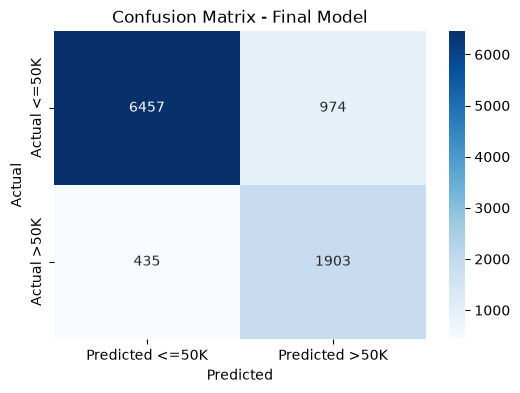

In [34]:
# Task 2 - Step 1
# Create the confusion matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

# Plot the confusion matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted <=50K', 'Predicted >50K'],
    yticklabels=['Actual <=50K', 'Actual >50K']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Model")

plt.show()

In [35]:
# Task 2 - Step 2
# Identify false positives and false negatives

tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 6457
False Positives: 974
False Negatives: 435
True Positives: 1903


In [36]:
# Task 2 - Step 3
# Analyze patterns in false positives and false negatives

# Create a table with actual and predicted values
error_data = X_test.copy()

error_data['actual'] = y_test.values
error_data['predicted'] = y_pred

# Find false positives
false_positives = error_data[
    (error_data['actual'] == 0) &
    (error_data['predicted'] == 1)
]

# Find false negatives
false_negatives = error_data[
    (error_data['actual'] == 1) &
    (error_data['predicted'] == 0)
]

print("Number of False Positives:", len(false_positives))
print("Number of False Negatives:", len(false_negatives))

print("\nFalse Positive Pattern:")
print(false_positives[['age', 'education-num', 'hours-per-week', 'capital-gain']].describe())

print("\nFalse Negative Pattern:")
print(false_negatives[['age', 'education-num', 'hours-per-week', 'capital-gain']].describe())

Number of False Positives: 974
Number of False Negatives: 435

False Positive Pattern:
              age  education-num  hours-per-week  capital-gain
count  974.000000     974.000000      974.000000    974.000000
mean    44.508214      11.030801       45.399384     79.207392
std     10.407792       2.072448       11.095940    714.808229
min     24.000000       4.000000        1.000000      0.000000
25%     36.000000       9.000000       40.000000      0.000000
50%     43.000000      10.000000       40.000000      0.000000
75%     51.750000      13.000000       50.000000      0.000000
max     90.000000      16.000000       99.000000  10566.000000

False Negative Pattern:
              age  education-num  hours-per-week  capital-gain
count  435.000000     435.000000      435.000000         435.0
mean    41.977011       9.898851       43.085057           0.0
std     12.492373       2.396978       11.645676           0.0
min     22.000000       2.000000        2.000000           0.0
25%   

In [37]:
# Task 2 - Step 4
# Analyze where the model performs well and where it struggles

from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.87      0.90      7431
           1       0.66      0.81      0.73      2338

    accuracy                           0.86      9769
   macro avg       0.80      0.84      0.82      9769
weighted avg       0.87      0.86      0.86      9769



## Task 2 - Model Behavior Analysis

### Where the Model Performs Well

The model performs well in identifying **Class 0**. It has a precision of **0.94** and an F1-score of **0.90**, which shows strong performance for this class.

### Where the Model Struggles

The model struggles more with **Class 1**. The precision for Class 1 is **0.66**, which is lower than Class 0. The model also produces more **False Positives (974)** than **False Negatives (435)**.

### Which Type of Error is More Costly?

In this project, **False Negatives** can be more costly because an actual positive case (income >50K) may be incorrectly predicted as negative. Missing a true positive case can be more important than incorrectly predicting a negative case as positive.

However, the actual cost depends on the real-world application.

### Practical Improvements

- Adjust the classification threshold to reduce false positives.
- Perform further hyperparameter tuning.
- Analyze additional features that may improve classification.
- Try other classification models and compare their performance.
- Use precision-recall analysis to select a suitable classification threshold.

In [62]:
# Task 3 - Step 1
# Get feature importance from the final model

final_model = gb_search.best_estimator_

feature_importance = final_model.feature_importances_

print("Feature importance:")
print(feature_importance)

AttributeError: 'Pipeline' object has no attribute 'feature_importances_'

In [ ]:
# Task 3 - Step 1
# Calculate feature importance

final_model = gb_search.best_estimator_

# Get the Gradient Boosting model from the pipeline
gb_model = final_model.named_steps['model']

# Get feature importance
feature_importance = gb_model.feature_importances_

print("Feature importance calculated successfully!")
print(feature_importance)

NameError: name 'gb_search' is not defined

In [ ]:
# Import GridSearchCV

from sklearn.model_selection import GridSearchCV

print("GridSearchCV imported successfully!")

GridSearchCV imported successfully!


In [ ]:
# Task 2: Hyperparameter Search for Gradient Boosting

gb_params = {
    'model__learning_rate': [0.01, 0.1],
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5]
}

gb_search = GridSearchCV(
    model_pipelines['Gradient Boosting'],
    param_grid=gb_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

print("Best parameters:", gb_search.best_params_)
print("Best score:", gb_search.best_score_)

NameError: name 'model_pipelines' is not defined

In [ ]:
# Create the model pipelines again

from sklearn.pipeline import Pipeline

model_pipelines = {}

for name, model in models.items():
    model_pipelines[name] = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

print("Model pipelines created successfully!")

NameError: name 'models' is not defined

In [ ]:
# Create the machine learning models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    )
}

print("Three models created successfully!")

Three models created successfully!


In [ ]:
# Create model pipelines

from sklearn.pipeline import Pipeline

model_pipelines = {}

for name, model in models.items():
    model_pipelines[name] = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

print("Model pipelines created successfully!")

NameError: name 'preprocessor' is not defined

In [ ]:
# Create model pipelines

from sklearn.pipeline import Pipeline

model_pipelines = {}

for name, model in models.items():
    model_pipelines[name] = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

print("Model pipelines created successfully!")

NameError: name 'preprocessor' is not defined

In [ ]:
numeric_features = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'has_capital_gain',
    'log_capital_gain',
    'higher_education',
    'education_hours_interaction'
]

categorical_features = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country',
    'age_group',
    'hours_group'
]

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 10
Categorical features: 10


In [ ]:
# Task 1: Create preprocessing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocess numerical features
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocess categorical features
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
from sklearn.pipeline import Pipeline

model_pipelines = {}

for name, model in models.items():
    model_pipelines[name] = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

print("Model pipelines created successfully!")

Model pipelines created successfully!


In [ ]:
# Task 2: Hyperparameter Search for Gradient Boosting

from sklearn.model_selection import GridSearchCV

gb_params = {
    'model__learning_rate': [0.01, 0.1],
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5]
}

gb_search = GridSearchCV(
    model_pipelines['Gradient Boosting'],
    param_grid=gb_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

print("Best parameters:", gb_search.best_params_)
print("Best score:", gb_search.best_score_)

NameError: name 'cv' is not defined

In [ ]:
# Create cross-validation strategy

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy created successfully!")

Cross-validation strategy created successfully!


In [ ]:
gb_search = GridSearchCV(
    model_pipelines['Gradient Boosting'],
    param_grid=gb_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

print("Best parameters:", gb_search.best_params_)
print("Best score:", gb_search.best_score_)

ValueError: 
All the 40 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Tooba Iqbal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_indexing.py", line 411, in _get_column_indices
    return [column_names.index(col) for col in selected_columns]
            ^^^^^^^^^^^^^^^^^^^^^^^
ValueError: 'has_capital_gain' is not in list

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\Tooba Iqbal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Tooba Iqbal\AppData\Loc

In [ ]:
print(X_train.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']


In [ ]:
# Create model pipelines with feature engineering

from sklearn.pipeline import Pipeline

model_pipelines = {}

for name, model in models.items():
    model_pipelines[name] = Pipeline([
        ('preprocessor', full_preprocessor),
        ('model', model)
    ])

print("Model pipelines created successfully!")

NameError: name 'full_preprocessor' is not defined

In [ ]:
# Combine feature engineering and preprocessing

from sklearn.preprocessing import FunctionTransformer

feature_engineering = FunctionTransformer(create_features)

full_preprocessor = Pipeline([
    ('feature_engineering', feature_engineering),
    ('preprocessing', preprocessor)
])

print("Full preprocessor created successfully!")

Full preprocessor created successfully!


In [ ]:
# Create model pipelines with feature engineering

model_pipelines = {}

for name, model in models.items():
    model_pipelines[name] = Pipeline([
        ('preprocessor', full_preprocessor),
        ('model', model)
    ])

print("Model pipelines created successfully!")

Model pipelines created successfully!


In [ ]:
from sklearn.model_selection import GridSearchCV

gb_params = {
    'model__learning_rate': [0.01, 0.1],
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5]
}

gb_search = GridSearchCV(
    model_pipelines['Gradient Boosting'],
    param_grid=gb_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

print("Best parameters:", gb_search.best_params_)
print("Best score:", gb_search.best_score_)

Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
Best score: 0.8729300183194002


In [ ]:
# Task 3 - Step 1
# Calculate feature importance

final_model = gb_search.best_estimator_

gb_model = final_model.named_steps['model']

feature_importance = gb_model.feature_importances_

print("Feature importance calculated successfully!")
print(feature_importance)

Feature importance calculated successfully!
[5.18390901e-02 1.71864781e-02 1.22712318e-01 7.71695815e-02
 6.42331747e-02 5.56033825e-03 3.82469786e-04 1.12796819e-01
 3.09937457e-03 9.83088864e-02 2.62897886e-03 1.72374876e-03
 0.00000000e+00 6.85046493e-04 1.44973209e-03 6.17990132e-03
 7.38349568e-04 4.02327278e-05 1.79512549e-04 2.08397120e-04
 1.26388457e-04 0.00000000e+00 9.27391354e-05 2.92453788e-05
 5.72131554e-05 6.32720988e-04 2.27259889e-04 1.34453947e-03
 4.70996460e-04 3.22890370e-04 6.76655475e-04 6.93028265e-05
 6.65473924e-04 3.63288324e-04 2.05412359e-04 7.80951649e-04
 3.64317582e-01 1.59682813e-04 1.01821944e-03 3.67708662e-04
 3.17927455e-04 9.29679847e-04 6.51899953e-05 5.33150671e-04
 1.43727598e-02 5.98467598e-03 1.27120948e-03 7.27807542e-04
 6.30539550e-03 2.55314074e-05 1.43762743e-03 8.48037580e-04
 1.23897857e-03 1.31242923e-03 9.40277549e-04 1.14300363e-03
 8.72856142e-04 2.96458217e-04 1.20295238e-04 2.88154374e-04
 5.13402367e-03 1.51512048e-04 6.51144194

In [ ]:
# Task 3 - Step 2
# Find the important features

feature_names = final_model.named_steps['preprocessor'].named_steps['preprocessing'].get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(
    'Importance',
    ascending=False
)

print("Top 10 Important Features:")
print(importance_df.head(10))

Top 10 Important Features:
                                   Feature  Importance
36  cat__marital-status_Married-civ-spouse    0.364318
2                       num__education-num    0.122712
7                    num__log_capital_gain    0.112797
9         num__education_hours_interaction    0.098309
3                        num__capital-gain    0.077170
4                        num__capital-loss    0.064233
0                                 num__age    0.051839
1                              num__fnlwgt    0.017186
44         cat__occupation_Exec-managerial    0.014373
48           cat__occupation_Other-service    0.006305


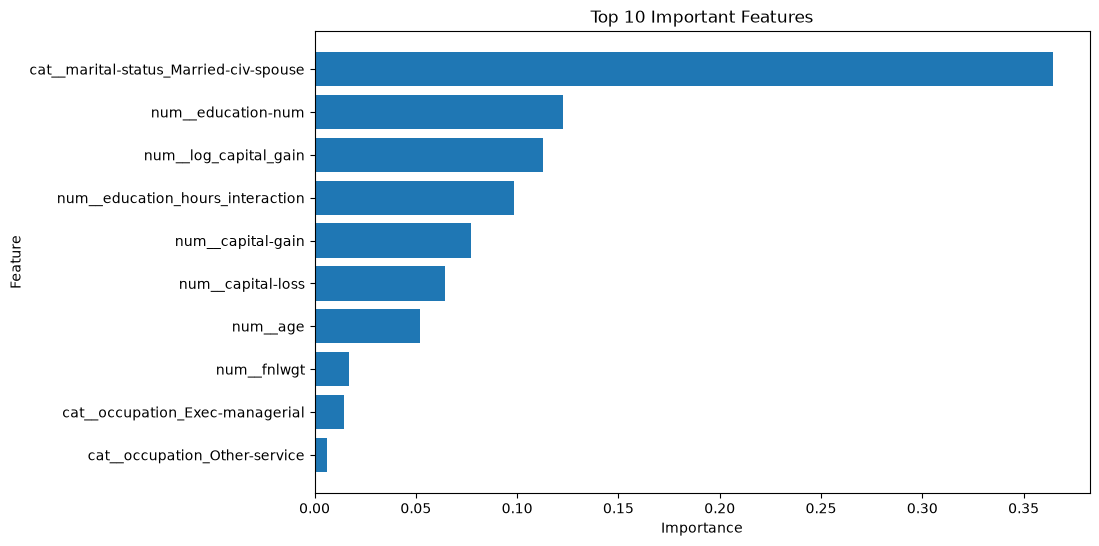

In [ ]:
# Task 3 - Step 3
# Plot Top 10 Important Features

top_features = importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Important Features')

plt.gca().invert_yaxis()

plt.show()

Feature Interpretation

The Gradient Boosting model uses several important features to make predictions.

The most important feature is marital-status_Married-civ-spouse. This feature has the highest importance in the model.

Other important features include **education-num, log_capital_gain, education_hours_interaction, capital-gain, capital-loss, and age**.

Higher education and capital gain can provide useful information for predicting income. Age and working hours can also help the model identify income patterns.

The model also gives importance to some occupation categories, such as Exec-managerial and **Other-service.

Some categorical features such as marital status and occupation may reflect patterns in the dataset. However, these features should be checked carefully because they can introduce bias.

Overall, the feature importannce results show that marital status, education, capital gain, education-hours interaction, and age are among the most influential features.

In [63]:
# Task 4 - Step 1
# Load the saved model

import joblib

model = joblib.load("final_model.joblib")

print("Model loaded successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'final_model.joblib'

In [64]:
# Task 4 - Step 1
# Load the saved model

import joblib

model = joblib.load("final_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [65]:
# Task 4 - Step 2
# Create new unseen examples

new_data = pd.DataFrame({
    'age': [25, 35, 45, 50, 30],
    'workclass': ['Private', 'Private', 'Private', 'Private', 'Private'],
    'fnlwgt': [100000, 150000, 200000, 180000, 120000],
    'education': ['Bachelors', 'HS-grad', 'Masters', 'Bachelors', 'Some-college'],
    'education-num': [13, 9, 14, 13, 10],
    'marital-status': ['Never-married', 'Married-civ-spouse', 'Married-civ-spouse', 'Married-civ-spouse', 'Never-married'],
    'occupation': ['Exec-managerial', 'Other-service', 'Exec-managerial', 'Sales', 'Sales'],
    'relationship': ['Not-in-family', 'Husband', 'Husband', 'Husband', 'Not-in-family'],
    'race': ['White', 'White', 'White', 'White', 'White'],
    'sex': ['Female', 'Male', 'Male', 'Male', 'Female'],
    'capital-gain': [0, 0, 5000, 0, 0],
    'capital-loss': [0, 0, 0, 0, 0],
    'hours-per-week': [40, 40, 50, 45, 35],
    'native-country': ['United-States'] * 5
})

print(new_data)

   age workclass  fnlwgt     education  education-num      marital-status  \
0   25   Private  100000     Bachelors             13       Never-married   
1   35   Private  150000       HS-grad              9  Married-civ-spouse   
2   45   Private  200000       Masters             14  Married-civ-spouse   
3   50   Private  180000     Bachelors             13  Married-civ-spouse   
4   30   Private  120000  Some-college             10       Never-married   

        occupation   relationship   race     sex  capital-gain  capital-loss  \
0  Exec-managerial  Not-in-family  White  Female             0             0   
1    Other-service        Husband  White    Male             0             0   
2  Exec-managerial        Husband  White    Male          5000             0   
3            Sales        Husband  White    Male             0             0   
4            Sales  Not-in-family  White  Female             0             0   

   hours-per-week native-country  
0              40  Un

In [66]:
# Task 4 - Step 3
# Get prediction probabilities

probability = model.predict_proba(new_data)[:, 1]

print("Prediction Probabilities:")
print(probability)

Prediction Probabilities:
[0.02215648 0.09225479 0.27556117 0.76819865 0.01909819]


In [67]:
# Task 4 - Step 4
# Apply the selected threshold

threshold = 0.3

prediction = (probability >= threshold).astype(int)

print("Final Predictions:")
print(prediction)

Final Predictions:
[0 0 0 1 0]


In [68]:
import sys
import pandas as pd
import sklearn
import numpy as np
import joblib

print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Scikit-learn version:", sklearn.__version__)
print("Joblib version:", joblib.__version__)

Python version: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Pandas version: 3.0.5
NumPy version: 2.5.2
Scikit-learn version: 1.9.0
Joblib version: 1.6.0


In [69]:

print("Best Parameters:")
print(gb_search.best_params_)


Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}


In [70]:
# Task 5 - Final Test Performance

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import brier_score_loss

# Get probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Apply threshold 0.3
y_pred = (y_prob >= 0.3).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
brier = brier_score_loss(y_test, y_prob)

print("Final Test Performance")
print("----------------------")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("Brier Score:", brier)

Final Test Performance
----------------------
Accuracy: 0.8557682464940116
Precision: 0.6614529023288147
Recall: 0.8139435414884517
F1 Score: 0.7298178331735379
ROC-AUC: 0.9291313560663437
PR-AUC: 0.8328504700271745
Brier Score: 0.08703117169437667
